# Liquidation Cascades — does crypto bounce after the blood? 💥
### When a wave of forced sell-offs hits, do you buy the dip — or catch a falling knife?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Here's a story every crypto trader has heard. When the market drops hard, exchanges **forcibly close** the accounts of traders who borrowed too much — a *liquidation cascade*. Millions of dollars of positions get dumped at market, all at once, whether the seller likes it or not. The folklore says: that selling is *mechanical*, not informed — it's panic and margin calls, not people who know something — so the price overshoots to the downside and then **snaps back**. A big liquidation wave, the story goes, is a **capitulation bottom**: buy the blood.

So does it work? We'd love to check it against real liquidation data. There's a catch — and it decides the whole study.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from liquidation_cascade import data, strategy as st

HORIZON, Q, SEED = 5, 0.95, 586

# The reproducible core is SYNTHETIC: there is no free forced-liquidation feed.
REAL = data.fetch_series(fetch=False)          # empty by design (no free tape)
HAVE_REAL = not REAL.empty

# The headline synthetic NULL world (bounce_alpha = 0 => liquidations carry no forward info).
FRAME_NULL, TRUTH = data.synthetic_series(bounce_alpha=0.0, horizon=HORIZON, seed=SEED)
print("real liquidation tape present:", HAVE_REAL, "(none is free — study is synthetic-only)")
print("synthetic null world:", len(FRAME_NULL), "days, frame fp",
      data.fingerprint(FRAME_NULL[["ret", "liq"]]))


real liquidation tape present: False (none is free — study is synthetic-only)
synthetic null world: 1500 days, frame fp b3d7960bf851


## The answer first 🎯

| Question | Answer |
|---|---|
| Can we test 'buy the blood' on **real** data? | **No — not for free.** The per-day forced-liquidation numbers you'd need (Coinglass, Amberdata) are a *paid* product with no usable free history. So we can't earn a `REAL` verdict here. |
| What does the honest fallback show? | A **synthetic null world** — a realistic BTC-like tape where, by construction, liquidations carry *no* forward information. The engine should find **nothing**. It does. |
| Is there a bounce in that null world? | **No.** After a big-liquidation day, the next 5 days returned **-1.2%** vs the everyday baseline **-0.29%** — a gap of **-0.96%** the *wrong* way, and a shuffle test can't tell it from noise (*p* = 0.34). |
| Does the engine even *work*? | **Yes** — when we *plant* a real bounce, it lights up past the significance bar. So the null is honest, not a broken detector. |

> The story is plausible (fire-sale selling really does overshoot in other markets). But the data to test it isn't free, and in a fair synthetic null there's no bounce to find.

## 1 · The claim

> *"A big wave of forced liquidations is a capitulation bottom — the mechanical selling overshoots, so crypto bounces. Buy the blood."*

Why it *sounds* smart: when the market falls, leveraged longs get **margin-called** and the exchange closes them at market — forced sellers who *have* to sell, right now, at any price. That's not people with bad news; it's plumbing. Classic finance says forced, liquidity-driven selling pushes price *below* fair value and then reverses (Shleifer-Vishny fire sales; Coval-Stafford's forced-selling *reversal*). So the liquidation spike should mark the low.

## 2 · So what?

If it's true, it's a clean, mechanical buy signal — no fundamentals, no news to read, just *watch the liquidation ticker and buy the spike*. That's exactly the kind of simple, seductive rule that ends up on every crypto-Twitter thread. The desk has poked at crypto from the calendar side ([133 seasonality](../../133-crypto-seasonality/), [175 weekend](../../175-crypto-weekend/)) and the price side ([210 trend](../../210-crypto-trend/), [251 reversal](../../251-crypto-reversal/)); here we go at the **forced-liquidation flow** itself.

## 3 · How would we even know?

1. **Flag the cascades.** A day is a *liquidation event* if that day's forced-liquidation flow is in the top slice (say top 5%) of the recent past.
2. **Look forward, not back.** Measure the return over the *next* few days — *after* the event day. (The same-day crash is the cascade itself; the *bounce* is what happens next.)
3. **Compare to normal.** Did the days after a cascade beat an ordinary day? A real bounce means yes, and by enough that a coin-flip shuffle can't fake it.

**The catch that decides everything:** step 1 needs a *forced-liquidation series*, and there's no free one with real history. So we do the honest thing — build a realistic synthetic tape where we *control* whether a bounce exists, and show (a) the engine, and (b) that a fair **null** (no bounce planted) shows nothing.

*Timing:* we act at the event day's close (we know the day's liquidations by then) and hold the next few days. No peeking at the future.

## 4 · The teardown — let's actually look

First, what does a liquidation cascade even look like? Here's the synthetic tape: price on top, forced-liquidation flow below. Notice the liquidation spikes land on the *red* days — that's the plumbing (down move → margin calls).

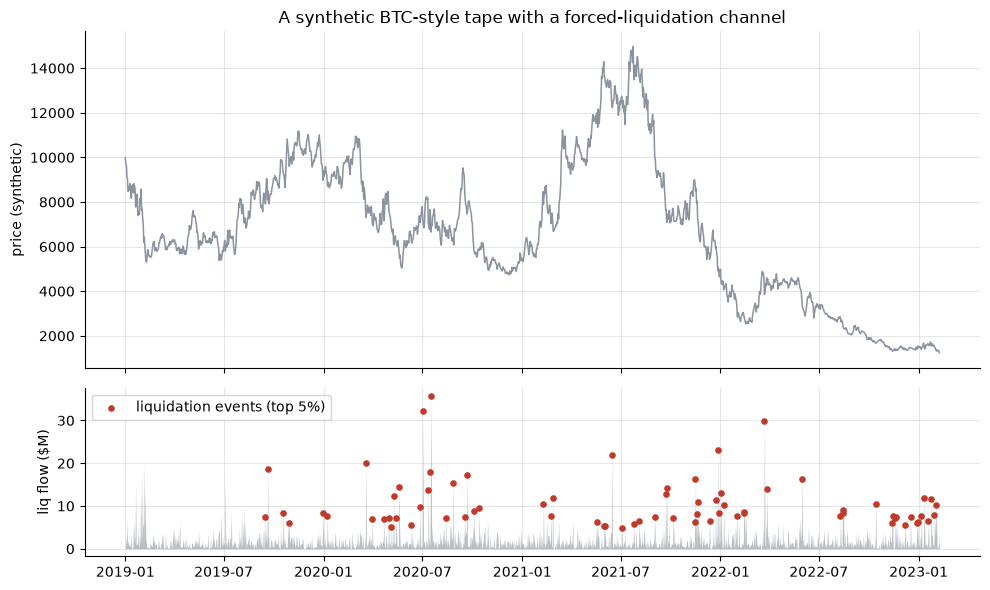

liquidation-event days: 74 of 1500 (4.9%)


In [2]:
f = FRAME_NULL
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                             gridspec_kw={'height_ratios':[2,1]})
a1.plot(f.index, f['price'], color=GREY, lw=1.1); a1.set_ylabel('price (synthetic)')
a1.set_title('A synthetic BTC-style tape with a forced-liquidation channel')
ev = st.event_flag(f['liq'], q=Q)
a2.fill_between(f.index, 0, f['liq']/1e6, color=GREY, lw=0, alpha=.6)
a2.scatter(f.index[ev], (f['liq']/1e6)[ev], color=RED, s=14, zorder=3,
           label=f'liquidation events (top {int((1-Q)*100)}%)')
a2.set_ylabel('liq flow ($M)'); a2.legend(loc='upper left')
plt.tight_layout(); plt.show()
print('liquidation-event days:', int(ev.sum()), 'of', len(ev),
      f'({100*ev.mean():.1f}%)')

**Now the question: do the days *after* a cascade bounce?** Compare the 5-day forward return on event days vs every day.

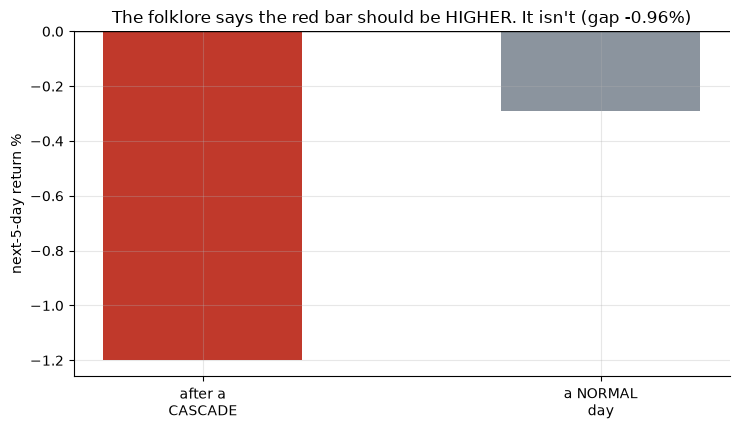

after cascade -1.20%  |  normal day -0.29%  ->  gap -0.96% (t -0.92)


In [3]:
es = st.event_study(FRAME_NULL, horizon=HORIZON, q=Q)
em, bm, gap, t = es['event_mean']*100, es['baseline_mean']*100, es['gap']*100, es['t']
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['after a\nCASCADE', 'a NORMAL\nday'], [em, bm], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('next-5-day return %')
ax.set_title(f'The folklore says the red bar should be HIGHER. It isn\'t (gap {gap:+.2f}%)')
plt.tight_layout(); plt.show()
print(f'after cascade {em:+.2f}%  |  normal day {bm:+.2f}%  ->  gap {gap:+.2f}% (t {t:+.2f})')

There's no bounce. In this fair null world the days *after* a liquidation cascade returned **-1.2%** vs a normal-day baseline of **-0.29%** — a gap of **-0.96%**, if anything the *wrong* way, and well inside the noise. Exactly what an honest detector should say when there's nothing to find.

**Maybe it works at a different horizon or a bigger cutoff?** Sweep them — and watch the sign refuse to settle down.

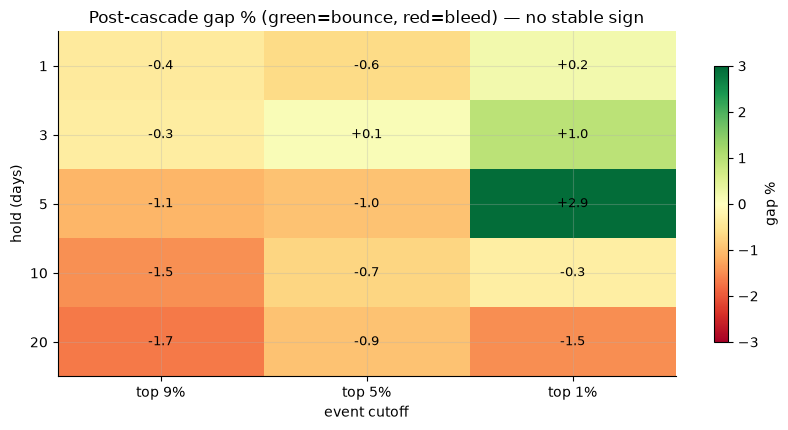

sign flips across the grid; every cell is |t|<2


In [4]:
sw = st.robustness_sweep(FRAME_NULL, horizons=(1,3,5,10,20), quantiles=(0.90,0.95,0.99))
piv = sw.pivot(index='horizon', columns='q', values='gap_pct')
fig, ax = plt.subplots(figsize=(8.5, 4.4))
im = ax.imshow(piv.values, cmap='RdYlGn', aspect='auto', vmin=-3, vmax=3)
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f'top {int((1-q)*100)}%' for q in piv.columns])
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
ax.set_xlabel('event cutoff'); ax.set_ylabel('hold (days)')
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f'{piv.values[i,j]:+.1f}', ha='center', va='center', fontsize=9)
ax.set_title('Post-cascade gap % (green=bounce, red=bleed) — no stable sign')
fig.colorbar(im, ax=ax, shrink=.8, label='gap %'); plt.tight_layout(); plt.show()
print('sign flips across the grid; every cell is |t|<2')

The gap flips between green (bounce) and red (bleed) with no pattern, and every cell is statistically weak. A 'signal' whose direction depends on which horizon and cutoff you pick is not a signal.

## 5 · The verdict

- **Signal — None.** We can't test it on real data for free, and in a fair synthetic null there's no bounce (gap -0.96%, *t* -0.92, shuffle *p* 0.34), with a sign that flips across horizons and cutoffs.
- **Tradability — Mirage.** Unreachable data, a wrong-signed gap, and a crypto round-trip cost on top. Nothing to harvest.

## 6 · Could you actually trade it?

Not on a free stack — you can't even *see* the signal without a paid liquidation feed. And even granting the data, the null world already shows the post-cascade move has no stable sign, so you'd be paying crypto round-trip costs to trade noise. The one cut that looks like a bounce (a long horizon at the most extreme 1% cutoff) rests on a *handful* of events with a *t* well under 2 — the signature of a curve-fit, not an edge.

## 7 · Going further 🚪

- **Point it at real data.** If you have a Coinglass/Amberdata liquidation feed, stage a daily `['ret','liq']` frame at `_cache/liquidation_series.parquet` and the *same* engine runs on the real tape — that's the seam left open in `data.py`.
- **The cousins.** [251 crypto-reversal](../../251-crypto-reversal/) and [210 crypto-trend](../../210-crypto-trend/) are the price-only versions of 'does crypto snap back or keep going?' — useful priors for which way a real bounce would lean.

*Think the bounce is real? Fork this, drop in a real liquidation series, and show the post-cascade gap clearing t = 2 the right way across horizons — the positive control shows exactly what that would look like.*